# Neuroevolution on a toy simulation

Fourth comparison/validation notebook (docs/design/0003 phase 5) â€” and the biggest architectural
jump so far: the genome (`evolve.neuro.WeightVector`, a small feedforward network's flattened
weights) isn't program-shaped at all, and fitness (`evolve.simulation.SimulationFitnessEvaluator`)
comes from running a stateful simulation (`reach1d.ReachTarget1D`) rather than comparing against a
static dataset. This is Evolution Strategies applied to a policy â€” docs/design/0003's "the case
where RL and EA are the same algorithm."

**A real bug, found by actually running this**: the environment's first version returned raw
`(position, velocity)` as the observation. Two benchmark scenarios starting at the same position
but with *different targets* were then observationally identical at reset â€” no policy could ever
solve both, no matter how well it evolved, since the observation didn't contain enough information
to determine the correct direction. Fixed by making the observation relative to the target
(`position - target`, `velocity`) instead of raw position â€” see `libs/reach1d/src/reach1d/env.py`.
Kept here as a fully genuine example of docs/design/0003's "illustrate failure modes" goal, not
cleaned out of the story.

In [1]:
import random
import statistics

import matplotlib.pyplot as plt

from evolve import GaussianMutation, SimulationFitnessEvaluator, TournamentSelection, evolve, random_weight_vector
from reach1d import benchmark_environments

## Setup

A small network (2 inputs: relative position + velocity; 8 hidden; 1 output: acceleration) evolved
with Gaussian mutation only (docs/design/0003 "standard neuroevolution/ES practice is mutation-
only" â€” see `evolve/neuro.py`), `TournamentSelection`, against `reach1d.benchmark_environments()`â€”
5 fixed scenarios, one fitness value (total episode reward) each, matching the same per-test-case
contract every other `FitnessEvaluator` in this repo follows.

In [2]:
LAYER_SIZES = (2, 8, 1)
POPULATION_SIZE = 80
GENERATIONS = 150
MAX_STEPS = 60
SEEDS = range(10)


def run_trial(seed):
    rng = random.Random(seed)
    population = [random_weight_vector(LAYER_SIZES, rng, scale=0.5) for _ in range(POPULATION_SIZE)]
    fitness = SimulationFitnessEvaluator(
        envs=benchmark_environments(), act=lambda g, obs: g.act(obs), max_steps=MAX_STEPS
    )
    summaries = []
    evolve(
        population,
        fitness=fitness,
        selection=TournamentSelection(k=4),
        variation=GaussianMutation(sigma=0.2),
        generations=GENERATIONS,
        on_generation=[summaries.append],
        rng=rng,
    )
    return summaries


trials = [run_trial(seed) for seed in SEEDS]

## Convergence

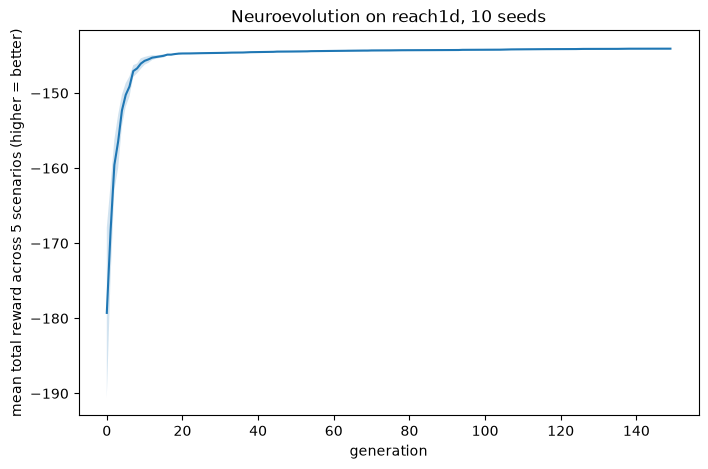

gen0 mean:  -179.28
final mean: -144.09


In [3]:
curves = [[s.best_fitness for s in summaries] for summaries in trials]
by_gen = list(zip(*curves))
means = [statistics.fmean(gen_values) for gen_values in by_gen]
stds = [statistics.pstdev(gen_values) for gen_values in by_gen]
generations = range(len(means))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(generations, means)
ax.fill_between(generations, [m - s for m, s in zip(means, stds)], [m + s for m, s in zip(means, stds)], alpha=0.2)
ax.set_xlabel("generation")
ax.set_ylabel("mean total reward across 5 scenarios (higher = better)")
ax.set_title(f"Neuroevolution on reach1d, {len(SEEDS)} seeds")
plt.show()

print(f"gen0 mean:  {means[0]:.2f}")
print(f"final mean: {means[-1]:.2f}")

## What the best evolved policy actually does

The champion from whichever of the 10 seeds reached the best final fitness, run on all 5 benchmark
scenarios (fresh episodes, not the ones it was scored on during evolution -- though since these
*are* the fixed benchmark, this is a check for "did it actually learn this," not held-out
generalization to a new scenario).

best seed: 0, final fitness: -144.00


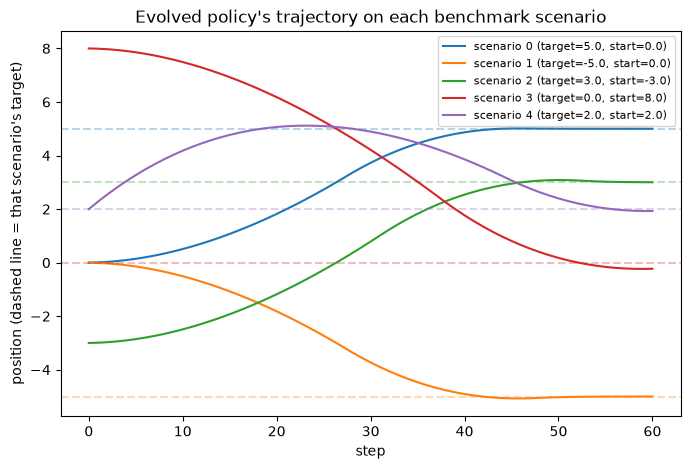

In [4]:
best_seed = max(range(len(trials)), key=lambda i: trials[i][-1].best_fitness)
champion = trials[best_seed][-1].champion
print(f"best seed: {best_seed}, final fitness: {trials[best_seed][-1].best_fitness:.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
for i, env in enumerate(benchmark_environments()):
    observation = env.reset()
    positions = [env.position]
    for _ in range(MAX_STEPS):
        action = champion.act(observation)
        observation, _reward, _done = env.step(action)
        positions.append(env.position)
    ax.plot(positions, label=f"scenario {i} (target={env.target}, start={env.start_position})")
    ax.axhline(env.target, linestyle="--", alpha=0.3, color=ax.lines[-1].get_color())

ax.set_xlabel("step")
ax.set_ylabel("position (dashed line = that scenario's target)")
ax.set_title("Evolved policy's trajectory on each benchmark scenario")
ax.legend(fontsize=8)
plt.show()

## Selection strategies still work unchanged

Not re-plotted in full here (notebooks 0001/0002 already made that comparison, twice) â€” but worth
stating plainly: `LexicaseSelection` and `ParetoSelection` (with `WeightVector.l2_norm()` as the
complexity objective) both run against this exact setup with zero changes, verified in
`libs/evolve/tests/test_neuro.py`. Every `SelectionStrategy` written against `case_fitnesses` alone
has now been proven generic across three genuinely different genome types: linear GP programs,
expression trees, and neural network weight vectors.

## Takeaways

- `SimulationFitnessEvaluator` validated end to end: a stateful environment, `reset()`/`step()`,
  reward accumulated over an episode, one fitness value per scenario â€” all without touching
  `evolve()`, `TournamentSelection`, or any other piece built for the dataset-based case.
- Genome-genericity now holds across the full range docs/design/0003 asked for: program-shaped
  (linear, tree) and non-program-shaped (weight vector) genomes, dataset-based and simulation-based
  fitness, all through the same `Population`/`SelectionStrategy`/`VariationStrategy` shape.
- The real lesson of this notebook: an environment's *observation* has to contain enough
  information to determine the correct action, or no amount of evolution can fix that â€” found by
  running the thing and noticing two scenarios could never both improve, not by reasoning about it
  in advance.
- Next per docs/design/0003's roadmap: LLM-in-the-loop variation (FunSearch-style) on an existing
  evaluator â€” the first `VariationStrategy` that isn't a fixed algorithm at all.